## Interpretability in a neural network

In [ ]:
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM
import matplotlib.pyplot as plt
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask
import torch 
import torch.nn.functional as F
import torchvision.transforms.functional as TF


Choose a pretrained model

Choose 3 classes present in the pre-trained weights of your chosen model.

1. 


For each class produce an attribution map for an image containing a positive example and a negative example.

Describe what you are seeing, what does the attribution maps show in each case? Analyze logits for similar activations for at least one example.

AND

At least 2 positive examples (images) - Look at several layers. Analyze the differences between early, middle and late layers. 

1 example of an image containing a class NOT present in the pre-trained model and analyse the result.



### Loading model and pretrained weights

In [3]:
weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()

## Creating a function to create the Class Attribution Maps

## Choosing 3 classes

### class 1: chow
one positive and negative example of the class

In [29]:
# preparing the CAM-extractor once
target_layer = model.layer4[-1]
cam_extractor = LayerCAM(model, target_layer=target_layer) # CAM-hooks are in the model, will register everything

def generate_cam(img_path, class_name):
    # load and preprocess pic
    preprocess = weights.transforms()
    img = decode_image(img_path)
    input_tensor = preprocess(img).unsqueeze(0) # preprocessing and adding batch dimension to image

    # forward pass
    out =  model(input_tensor) # here are the logits for all classes
    logits = out.squeeze(0)

    # find class index from class 
    class_idx = weights.meta["categories"].index(class_name)
        
    # get CAM
    activation_map = cam_extractor(class_idx, out)[0]

    # scale up CAM to pic size
    H, W = img.shape[-2:]

    cam = F.interpolate(
        activation_map.unsqueeze(0).unsqueeze(0),   # (1,1,7,7)
        size=(H, W),  # (H, W) = (819, 1024)
        mode="bicubic",
        align_corners=False
    ).squeeze()

    # normalize CAM
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    # plot overlay
    plt.imshow(img.permute(1,2,0))
    plt.imshow(cam.cpu(), cmap='jet', alpha=0.5)
    plt.axis('off')
    plt.show()

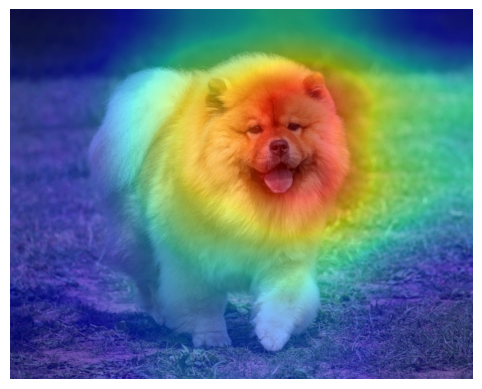

In [30]:
generate_cam("chow_chow.jpg", "chow")

(np.float64(-0.5), np.float64(473.5), np.float64(473.5), np.float64(-0.5))

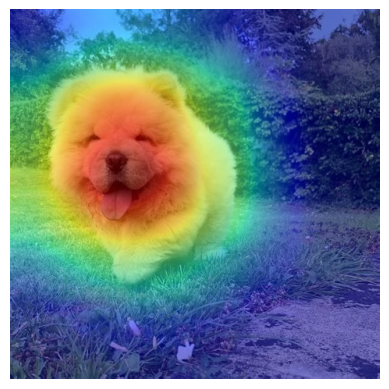

In [28]:
# positive example of the class

preprocess = weights.transforms()
img1 = decode_image("chow_chow1.jpg") # loading pic as a PyTorch tensor 

input_tensor = preprocess(img1).unsqueeze(0) # preprocessing and adding batch dimension to image

target_layer = model.layer4[-1]

cam_extractor = LayerCAM(model, target_layer=target_layer) # CAM-hooks are in the model, will register everything

out =  model(input_tensor) # forward pass
# here are the logits for all classes

class_idx = out.squeeze(0).argmax().item()

# LayerCAM returns a list; take the first heatmap
activation_map = cam_extractor(class_idx, out)[0]

# resize CAM to image size

H, W = img1.shape[-2:]

cam = F.interpolate(
    activation_map.unsqueeze(0).unsqueeze(0),   # (1,1,7,7)
    size=(H, W),  # (H, W) = (819, 1024)
    mode="bicubic",
    align_corners=False
).squeeze()

# normalize CAM
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)

plt.imshow(img1.permute(1,2,0))
plt.imshow(cam.cpu(), cmap='jet', alpha=0.5)
plt.axis('off')

What does the class attribution map show?

Let's check out the logits for the positive example of the first class

In [24]:
out

tensor([[-3.4023e-01, -1.8881e+00, -1.4975e+00, -4.1342e+00, -3.1426e+00,
          1.4393e+00, -1.4177e+00, -1.2808e+00,  7.1743e-01, -1.0004e+00,
         -4.1973e+00, -6.3485e+00, -4.2357e+00, -5.4102e+00, -2.2460e+00,
         -5.1513e+00, -3.3327e+00, -3.1916e+00, -4.0147e+00, -4.3412e+00,
         -4.1627e+00, -4.7228e+00, -4.6092e+00, -8.9359e-01, -2.7794e-01,
         -1.6218e+00, -1.4071e+00, -1.9515e+00, -2.5708e-01, -2.7638e+00,
         -7.3529e-01, -1.8194e+00, -1.3985e+00, -1.6538e+00, -4.0980e-01,
         -1.5838e+00, -1.9247e+00, -3.9812e+00, -3.5822e+00, -2.1537e+00,
         -1.6479e+00, -2.6663e+00, -3.3907e+00, -1.9442e+00, -8.8267e-01,
         -3.1193e+00, -2.5557e+00,  3.5752e-01, -2.3103e+00,  6.9924e-01,
         -1.4400e+00,  7.6323e-01, -2.3579e+00, -1.0837e+00, -1.2980e+00,
         -1.4725e+00,  9.0399e-01, -2.9988e+00, -2.5604e+00, -2.4222e+00,
         -1.7876e-01,  2.1099e-01,  1.0199e-01, -2.2983e-02, -6.8277e-01,
         -9.9294e-02,  1.0711e+00, -1.

Not easy to find the highest values among the logits.

In [26]:
logits = out.squeeze(0)
top5_vals, top5_idxs = torch.topk(logits,5)

print("Top 5 classes:")
for val, idx in zip(top5_vals, top5_idxs):
    print(f"{idx.item():4d}  {val.item():.4f}  {weights.meta['categories'][idx]}")

Top 5 classes:
 260  21.2909  chow
 244  13.1166  Tibetan mastiff
 258  12.0846  Samoyed
 259  10.3855  Pomeranian
 261  9.8239  keeshond


These are the classes that the model find most probable for the image. We can make a CAM for the second highest class and compare to see if they activate the same regions?

In [8]:
#negative example of the class


### class 2: rapeseed

### class 3: lakeside 

### Interpretability



#### I. Feature attribution
with CAM

CAM visar var i bilden modellen tittar.

#### II. Feature visualization

Feature visualization med FEATURE MAPS från valda lager visar vad filtret föredrar som input.

Du skickar in en bild i modellen och plockar ut feature maps från ett visst lager. Sen visualiserar du som en gråskale-bild. 